In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import scipy.stats as stats
import matplotlib.pyplot as plt

# This file has age associated trends of porphyromonas and conchiformibius with age
# Used qc2 (you have to change the file paths)
# Calculated spearman correlation coefficients and p values with age to add to the manuscript too

In [12]:
qc2 = pd.read_csv("qc2_duplicates_cluster1_and_minus1_removed.csv", low_memory=False)
print(qc2.shape, "Shape of qc2")

(1043, 1583) Shape of qc2


In [13]:
# Pick out genus cols

g_cols = []

for col in qc2.columns: # for each column in the dataframe (Col)
    if "|g__" in col: # If the column name contains "g__" (Genus)
        if "|s__" not in col: # If the column name does not contain "s__" (Species): Genus > Species
            segments = col.split("|") # Split the column name by "|" into segments
            end_segment = segments[-1] # Get the end segment of the column name
            if not end_segment.startswith("g__GGB"): # If the end segment does not start with "g__GGB" (Genus GGB)
                g_cols.append(col) # Append the column name to the list of genus columns

print(len(g_cols), "Number of genus columns")

190 Number of genus columns


In [14]:
# Recalculate the porportions:  divide each genus column by the sum of all genus columns for that row

per_dawg_genus_total_abund = qc2[g_cols].sum(axis=1) # Take the cols of interest > Add abundances per row (axis=1) for each dog

per_dawg_genus_p_rescaled = qc2[g_cols].div(per_dawg_genus_total_abund, axis=0) # Genus col > divide by total abundance for the row or sample 
# AKA (axis=0 or per row)

# Sanity check:  Check that the sum of the proportions for each row is equal to 1
total_porports = per_dawg_genus_p_rescaled.sum(axis=1) # Rescaled proportions > Add the proportions for each row (axis=1)

# Min and max should be ~ 1
print(total_porports.min(), "Min of the rescaled total proportions")
print(total_porports.max(), "Max of the rescaled total proportions")

print("SHAPE of the entire rescaled prportions dataframe: ", per_dawg_genus_p_rescaled.shape)

0.9999999999999994 Min of the rescaled total proportions
1.0000000000000007 Max of the rescaled total proportions
SHAPE of the entire rescaled prportions dataframe:  (1043, 190)


In [15]:
# Build the dataframe with all the data (sample name, metadata, and the rescaled proportions of porphyromonas and conchiformibius)

# Set up blank conchiformibius and porphyromonas column names for search to find the genus columns of interest
conchiformibius_column = "" # Empty string that will eventually hold the column name for the respective genus of interest
porphyromonas_column = ""  # Need to find the actual col names in next part of the code

for col in g_cols: # For each genus column name in the list of genus columns
    if col.endswith("g__Conchiformibius"): # If the column name ends with "g__Conchiformibius" > PATTERN: Last part ends with the genus name (g__)
        conchiformibius_column = col
    if col.endswith("g__Porphyromonas"): # If the column name ends with "g__Porphyromonas"
        porphyromonas_column = col

# Create a new dataframe

# Empty one to start
scatter_df = pd.DataFrame()
# Sample id, age, weight and conchiformibius/porphyromonas in that order
scatter_df["sample_id"] = qc2["sample_id"] # Make a col named sample_id and fill it with the sample_id col from qc2
scatter_df["age"] = qc2["age"] # Make a col named age and fill it with the age col from qc2
scatter_df["weight"] = qc2["weight"] # Make a col named weight and fill it with the weight col from qc2
scatter_df["g__Conchiformibius"] = per_dawg_genus_p_rescaled[conchiformibius_column] # Make a col named conchiformibius and fill it with the rescaled conchiformibius col 
scatter_df["g__Porphyromonas"] = per_dawg_genus_p_rescaled[porphyromonas_column] # Make a col named porphyromonas and fill it with the rescaled porphyromonas col from qc2

# Show the full shape and display the head
print("SHAPE:", scatter_df.shape)
display(scatter_df.head())

SHAPE: (1043, 5)


,sample_id,age,weight,g__Conchiformibius,g__Porphyromonas
0,DW31240510808865,5.0,170.0,0.101479,0.334698
1,DW31240510802107,1.0,166.0,0.732658,0.095358
2,DW31240510806513,6.0,166.0,0.264168,0.084702
3,DW31240510806340,4.0,165.0,0.100390,0.007193
4,DW31240663106415,3.0,165.0,0.016491,0.669052


In [16]:
# Check distribution of the rescaled proportions for conchiformibius and porphyromonas

print("Dist. of Rescaled Proportions of g__Conchiformibius:")

# Conchiformibius data > Assign to a variable so u don't retype
conchiformibius_data = scatter_df["g__Conchiformibius"]

print("Minimum = ", conchiformibius_data.min()) # Check the min of the rescaled proportions for conchiformibius
print("Maximum = ", conchiformibius_data.max()) # Check the max of the rescaled proportions for conchiformibius
print("Number of 0's = ", (conchiformibius_data == 0).sum()) # Check for the number of 0's and sum them
print("Median = ", conchiformibius_data.median()) # Check the median of the rescaled proportions for conchiformibius

print("\nDist. of Rescaled Proportions of g__Porphyromonas:")

porphyromonas_data = scatter_df["g__Porphyromonas"] # Assign Porphyromonas to a variable so u don't retype

print("Minimum = ", porphyromonas_data.min()) # Min
print("Maximum = ", porphyromonas_data.max()) # Max
print("Number of 0's = ", (porphyromonas_data == 0).sum()) # Num of 0's
print("Median = ", porphyromonas_data.median()) # Median


Dist. of Rescaled Proportions of g__Conchiformibius:
Minimum =  0.0
Maximum =  1.0
Number of 0's =  64
Median =  0.07127729141615408

Dist. of Rescaled Proportions of g__Porphyromonas:
Minimum =  0.0
Maximum =  0.9003183951013205
Number of 0's =  163
Median =  0.21052872428319855


Now time for the age analysis

In [17]:
# LOESS: Age and Porphyromonas

age_log_transform = np.log10(scatter_df["age"]) # Log transform the age data for better visualization

loess_age_porphyromonas = sm.nonparametric.lowess(scatter_df["g__Porphyromonas"], age_log_transform,
                                                 frac=0.65,
                                                 it=0 # Doesn't iterate, 0 abundances aren't weighted less and treated as outliers (all pts =)
                                                ) # LOESS: Porphyromonas vs Age
# frac = smoothness
loess_x_age_p = 10 ** loess_age_porphyromonas[:, 0] # x-axis values, raise 10 to the power of the log transformed age values 
# to get back to the original scale
loess_y_age_p = loess_age_porphyromonas[:, 1] # y-axis values

kept_fit_line_p = (loess_x_age_p >= 0.1) & (loess_y_age_p >= 0) # Keep only the values above 0 or = 0, the filter you could say
# Keep only the ages above 0.1 years because the loess line isn't accurate below that age

# Applying the kept_fit_line filter to the loess x and y values to keep only the values above 0 or = 0

# Removed some of the loess values in the fit line, so I need to make sure the corresponding x values are kept/aligned to the y's
loess_x_age_p = loess_x_age_p[kept_fit_line_p] # Keep only the x-axis values that correspond to the y-axis values above 0
loess_y_age_p = loess_y_age_p[kept_fit_line_p] # Keep only the y-axis values that are above 0

# The loess fit line is stored in two different lists of x and y values, so you need to make sure they are the same length and the 
# corresponding x and y values are aligned (the same are removed i.e.)


# LOESS: Age and Conchiformibius
loess_age_conchiformibius = sm.nonparametric.lowess(scatter_df["g__Conchiformibius"], age_log_transform,
                                                    frac=0.65,
                                                    it=0
                                                   ) # LOESS: Conchiformibius vs Age
loess_x_age_c = 10 ** loess_age_conchiformibius[:, 0] # x-axis values (age), to the power of 10 to undo the log transformation
loess_y_age_c = loess_age_conchiformibius[:, 1] # y-axis values (porportions)

kept_fit_line_c = (loess_x_age_c >= 0.1) & (loess_y_age_c >= 0) # Keep only the values above 0 or = 0, the filter you could say

# Applying the kept_fit_line filter to the loess x and y values to keep only the values above 0 or = 0
loess_x_age_c = loess_x_age_c[kept_fit_line_c] # Keep only the x-axis values that correspond to the y-axis values above 0
loess_y_age_c = loess_y_age_c[kept_fit_line_c] # Keep only the y-axis values that are above 0

Spearman correlation and p-value (age and porphyromonas): 0.5894584419087567 1.3318634061794549e-98


(0.01369853228576156, 23.86555480398497)

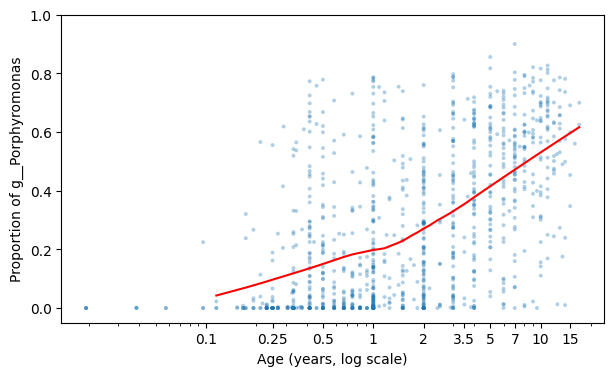

In [18]:
# Age and Porphyromonas

fig, ax = plt.subplots(figsize = (7,4)) # Set up the figure 
ax.scatter(scatter_df["age"], scatter_df["g__Porphyromonas"],  # Scatter plot of age `vs Porphyromonas (x,y)
           alpha=0.35, # Adjust alpha for transparency of the points
           edgecolors='none', # No edge colors for the points ,
           s=8 # Dot area (pts)

           ) 

# Plot LOESS
ax.plot(loess_x_age_p, loess_y_age_p, color='red', linewidth=1.5) # (x, y, color, linewidth)

# Spearman correlation
corr_agep, p_agep = stats.spearmanr(scatter_df["age"], scatter_df["g__Porphyromonas"]) # Spearman correlation between age and Porphyromonas
print("Spearman correlation and p-value (age and porphyromonas):", corr_agep, p_agep)

age_x_vals = [0.1, 0.25, 0.5, 1, 2, 3.5, 5, 7, 10, 15] # I want to label the x-axis with the age of the dogs since we're doing log scale
age_x_labels = ["0.1", "0.25", "0.5", "1", "2", "3.5", "5", "7", "10", "15"] # The labels for the x-axis
ax.set_xscale('log') # Set the x-axis to log scale
ax.set_xticks(age_x_vals) # Set the x-ticks to the age values
ax.set_xticklabels(age_x_labels) # set the x-tick labels to the age x labels
ax.set_ylim(-0.05, 1) # Set the y-axis limits to 1

ax.set_xlabel("Age (years, log scale)") # Set the x-axis label
ax.set_ylabel("Proportion of g__Porphyromonas") # Set the y-axis label

ax.get_xlim() # Get the x-axis limits
# Set the x-axis limits based on the current x-axis limit
ax.set_xlim([ax.get_xlim()[0], ax.get_xlim()[1]]) # Set the x-axis limits based on the current x-axis limit




Spearman correlation and p-value (age and conchiformibius): -0.4233328560030384 1.3247458479774487e-46


(0.01369853228576156, 23.86555480398497)

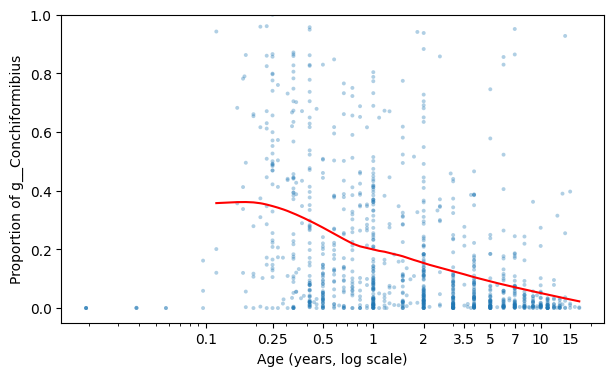

In [19]:
# Age and Conchiformibius

fig, ax = plt.subplots(figsize = (7,4)) # Set up the figure 
ax.scatter(scatter_df["age"], scatter_df["g__Conchiformibius"],  # Scatter plot of age `vs Conchiformibius (x,y)
           alpha=0.35, # Adjust alpha for transparency of the points
           edgecolors='none', # No edge colors for the points ,
           s=8 # Dot area (pts)

           ) 

# Plot LOESS
ax.plot(loess_x_age_c, loess_y_age_c, color='red', linewidth=1.5) # (x, y, color, linewidth)

# Spearman correlation
corr_agec, p_agec = stats.spearmanr(scatter_df["age"], scatter_df["g__Conchiformibius"]) # Spearman correlation between age and Conchiformibius
print("Spearman correlation and p-value (age and conchiformibius):", corr_agec, p_agec)

age_x_vals = [0.1, 0.25, 0.5, 1, 2, 3.5, 5, 7, 10, 15] # I want to label the x-axis with the age of the dogs since we're doing log scale
age_x_labels = ["0.1", "0.25", "0.5", "1", "2", "3.5", "5", "7", "10", "15"] # The labels for the x-axis
ax.set_xscale('log') # Set the x-axis to log scale
ax.set_xticks(age_x_vals) # Set the x-ticks to the age values
ax.set_xticklabels(age_x_labels) # set the x-tick labels to the age x labels
ax.set_ylim(-0.05, 1) # Set the y-axis limits to 1

ax.set_xlabel("Age (years, log scale)") # Set the x-axis label
ax.set_ylabel("Proportion of g__Conchiformibius") # Set the y-axis label

ax.get_xlim() # Get the x-axis limits
# Set the x-axis limits based on the current x-axis limit
ax.set_xlim([ax.get_xlim()[0], ax.get_xlim()[1]]) # Set the x-axis limits based on the current x-axis limit



Weight analysis

In [20]:
# Build the dataframe for the weight
weight_analysis_df = scatter_df.dropna(subset=["weight", "g__Porphyromonas", "g__Conchiformibius"]) 
# Build a new dataframe with only the weight and the two genus columns